# Completing Random Forest Analysis
Assumption that appropriate separation and PCA has been completed.

## SETUP

In [1]:
import subprocess, sys, os, importlib, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rf_functions 
importlib.reload(rf_functions)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# STEP 0 : LOAD THE ADSORPTION ENERGY DATA

def overall_rf(transformed_data_dir, dataset):
    adsorption_energy_df = pd.read_excel('Adsorption_energies_additives.xlsx')

    # Initialize an empty list to store the results
    results = []
    
    files = [f for f in os.listdir(transformed_data_dir) if f.startswith('transformed')]

    for filename in files:
        filepath = os.path.join(transformed_data_dir, filename)

        # Load and process the data
        pca_data = rf_functions.load_pca_transformed_data(filepath)
        merged_data = rf_functions.adsorption_energy_for_dataset(pca_data, adsorption_energy_df)

        # Perform Random Forest and get mse and r2
        mae, mse, rmse, r2, adjusted_r2 = rf_functions.perform_random_forest(merged_data)

        # Extract the energy range and cumulative variance ratio from the filename
        energy_range_match = re.search(r'\[([-+]?\d*\.\d+|\d+),([-+]?\d*\.\d+|\d+)\]', filename)
        cum_variance_match = re.search(r'var([\d\.]+)', filename)

        if energy_range_match and cum_variance_match:
            energy_range = f"{energy_range_match.group(1)},{energy_range_match.group(2)}"
            cum_variance = cum_variance_match.group(1).rstrip('.')

            # Append the results to the list as a dictionary
            results.append({
                'dataset': dataset.replace('transformed_data_', ''),
                'energy_range': energy_range,
                'cum_variance': cum_variance,
                'n_pc': pca_data.shape[1] - 1,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'R^2': r2,
                'Adjusted_R^2': adjusted_r2
            })

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(results)

    # Define the output CSV file path
    output_path = os.path.join(transformed_data_dir, 'rf_results.txt')

    # Save the DataFrame to a CSV file
    results_df.to_csv(output_path, sep='\t', index=False)

    return results_df

In [3]:
# Create an empty DataFrame
overall_results = pd.DataFrame(columns=['dataset',
                                        'energy_range',
                                        'cum_variance',
                                        'n_pc',
                                        'MAE',
                                        'MSE',
                                        'RMSE',
                                        'R^2',
                                        'Adjusted_R^2'], dtype='float64')

overall_results

,dataset,energy_range,cum_variance,n_pc,MAE,MSE,RMSE,R^2,Adjusted_R^2


In [4]:
base_dir = os.getcwd()

transformed_data_dirs = [f for f in os.listdir(base_dir) if f.startswith('transformed_data')]

for dir in transformed_data_dirs:
    print(f"Processing directory is {dir}")
    dir_path = os.path.join(base_dir, dir)
    cur_results = overall_rf(dir_path, dir)
    overall_results = pd.concat([overall_results, cur_results], ignore_index=True).drop_duplicates()

overall_results

Processing directory is transformed_data_DOSCAR_Files


,dataset,energy_range,cum_variance,n_pc,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,DOSCAR_Files,"-1.46,3.27",0.80,2.0,0.178832,0.054292,0.233005,-0.310061,-0.358582
1,DOSCAR_Files,"-1.46,3.27",0.90,5.0,0.134002,0.031586,0.177725,0.237822,0.163098
2,DOSCAR_Files,"-10.00,10.00",0.80,19.0,0.121423,0.027790,0.166702,0.329432,-0.014914
3,DOSCAR_Files,"-10.00,10.00",0.90,36.0,0.130063,0.030176,0.173713,0.271847,-1.038827
4,DOSCAR_Files,"-5.00,5.00",0.80,13.0,0.148975,0.040175,0.200438,0.030563,-0.262523
5,DOSCAR_Files,"-5.00,5.00",0.90,23.0,0.152554,0.038339,0.195804,0.074867,-0.569923


In [5]:
## FOR PLOTTING y_test vs y_pred

adsorption_energy_df = pd.read_excel('Adsorption_energies_additives.xlsx')

def plot_rf_results(transformed_data_dir, filename, energy_range, variance):

    filepath = os.path.join(transformed_data_dir, filename)

    # Load and process the data
    pca_data = rf_functions.load_pca_transformed_data(filepath)
    merged_data = rf_functions.adsorption_energy_for_dataset(pca_data, adsorption_energy_df)

    # Prepare the data
    x = merged_data.drop(columns=['Molecule','Ads.'])
    y = merged_data['Ads.']

    # Split the data

    x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

    ## Train the Random Forest Model

    # Initialize and fit the model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(x_train, y_train)

    ## Make predictions and evaluate the model

    # Predictions
    y_pred = rf_model.predict(x_test)

    # Extract sample indices from the first column of y_test (if it's a DataFrame)
    y_actual = y_test.values

    # Calculate axis limits for equal scaling
    min_val = min(y_actual.min(), y_pred.min()) - 0.2
    max_val = max(y_actual.max(), y_pred.max()) + 0.2

    # Plot actual vs predicted with y=x line
    plt.figure(figsize=(8, 8))
    plt.plot(y_actual, y_pred, 'o', markersize=6, label='Predictions')
    plt.plot([min_val, max_val], [min_val, max_val], 'r-', label='$y = x$', linewidth=2)  # y=x line

    plt.xlabel('Actual Adsorption Energy')
    plt.ylabel('Predicted Adsorption Energy')
    plt.title(f'Actual vs Predicted Adsorption Energy for {energy_range} and {variance * 100}% variance')
    plt.legend()
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True)
    plt.show()

## FOR DATASET 1

In [28]:
transformed_data_dir = os.path.join(os.getcwd(),'transformed_data_DOSCAR_files_1st_Initial')

cur_results_set_1 = overall_rf(transformed_data_dir, 'Initial_set')
cur_results_set_1 

,dataset,energy_range,cum_variance,n_pc,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,Initial_set,"-10.00,10.00",0.80,11,0.187053,0.046905,0.216575,-0.243396,-2.978866
1,Initial_set,"-10.00,10.00",0.90,22,0.200418,0.049902,0.223388,-0.322852,4.527605
2,Initial_set,"-11.44,4.12",0.80,13,0.193641,0.051453,0.226832,-0.363953,-6.274415
3,Initial_set,"-11.44,4.12",0.90,24,0.199829,0.050303,0.224282,-0.333464,3.666928
4,Initial_set,"-5.00,5.00",0.80,8,0.219394,0.068108,0.260974,-0.805458,-2.610916
5,Initial_set,"-5.00,5.00",0.90,15,0.241112,0.072142,0.268593,-0.912413,-29.598614


## FOR DATASET 1-5

In [29]:
transformed_data_dir = os.path.join(os.getcwd(),'transformed_data_DOSCAR_files_2nd_Extended')

cur_results_set_5 = overall_rf(transformed_data_dir, 'Extended_set')
cur_results_set_5

,dataset,energy_range,cum_variance,n_pc,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,Extended_set,"-1.46,3.27",0.80,10,0.170126,0.046603,0.215877,0.113513,-0.255857
1,Extended_set,"-1.46,3.27",0.90,14,0.161143,0.042917,0.207164,0.183625,-0.387837
2,Extended_set,"-10.00,10.00",0.80,39,0.146506,0.040639,0.201590,0.226965,6.256637
3,Extended_set,"-10.00,10.00",0.90,57,0.158680,0.046272,0.215109,0.119804,2.301159
4,Extended_set,"-5.00,5.00",0.80,25,0.154837,0.037570,0.193829,0.285343,-1.699817
5,Extended_set,"-5.00,5.00",0.90,36,0.160546,0.040797,0.201984,0.223943,14.192971


In [30]:
adsorption_energy_df = pd.read_excel('Adsorption_energies_additives.xlsx')

transformed_data_dir = os.path.join(os.getcwd(),'transformed_data_DOSCAR_files_2nd_Extended')
transformed_data_dir


'c:\\Users\\jespe\\Desktop\\[THESIS] Code\\-ESPEJO-THESIS-DOS-ML-Model-\\SCRIPTS_RANDOM_FOREST\\transformed_data_DOSCAR_files_2nd_Extended'

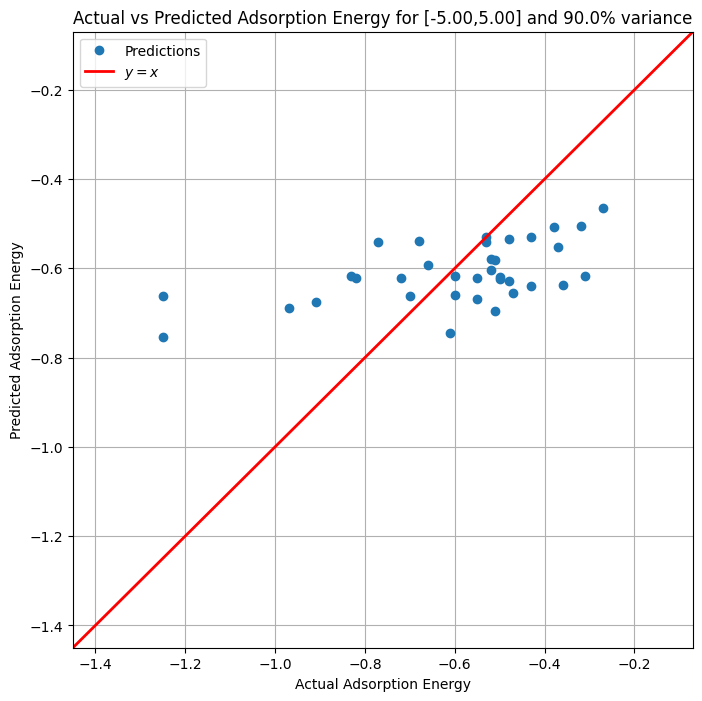

In [31]:
### FOR -5.00, 5.00 AND 90% VARIANCE

energy_range = '[-5.00,5.00]'
variance = 0.90

transformed_data_dir = os.path.join(os.getcwd(),'transformed_data_DOSCAR_files_2nd_Extended')
filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

plot_rf_results(transformed_data_dir, filename, energy_range, variance)


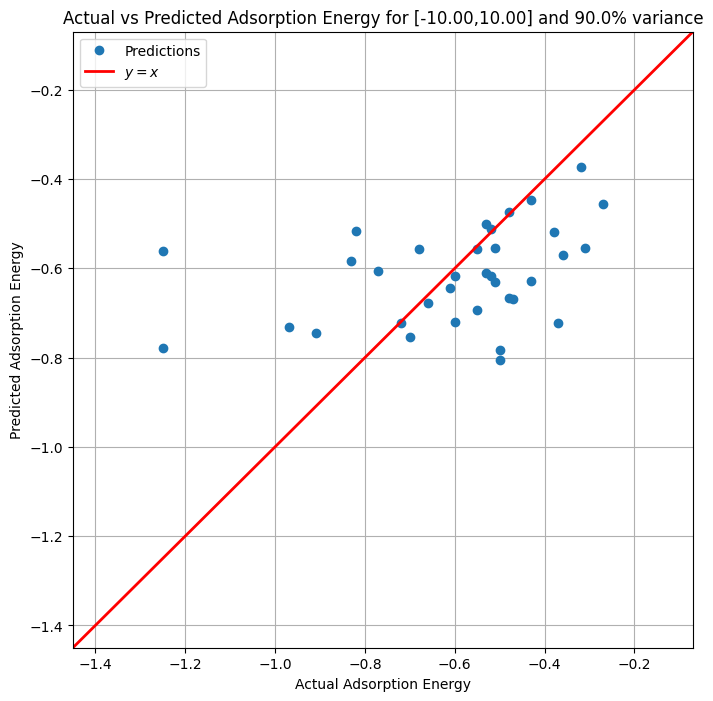

In [32]:
### FOR -10.00, 10.00 AND 90% VARIANCE

energy_range = '[-10.00,10.00]'
variance = 0.90

transformed_data_dir = os.path.join(os.getcwd(),'transformed_data_DOSCAR_files_2nd_Extended')
filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

plot_rf_results(transformed_data_dir, filename, energy_range, variance)

In [34]:
combined_df = pd.concat([cur_results_set_1, cur_results_set_5], ignore_index=True).drop_duplicates()
combined_df

# Save DataFrame to an Excel file
output_file = 'output_file.xlsx'
combined_df.to_excel(output_file, index=False)  # Set index=False to exclude the index column
print(f"DataFrame saved to {output_file}")

combined_df

DataFrame saved to output_file.xlsx


,dataset,energy_range,cum_variance,n_pc,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,Initial_set,"-10.00,10.00",0.80,11,0.187053,0.046905,0.216575,-0.243396,-2.978866
1,Initial_set,"-10.00,10.00",0.90,22,0.200418,0.049902,0.223388,-0.322852,4.527605
2,Initial_set,"-11.44,4.12",0.80,13,0.193641,0.051453,0.226832,-0.363953,-6.274415
3,Initial_set,"-11.44,4.12",0.90,24,0.199829,0.050303,0.224282,-0.333464,3.666928
4,Initial_set,"-5.00,5.00",0.80,8,0.219394,0.068108,0.260974,-0.805458,-2.610916
5,Initial_set,"-5.00,5.00",0.90,15,0.241112,0.072142,0.268593,-0.912413,-29.598614
6,Extended_set,"-1.46,3.27",0.80,10,0.170126,0.046603,0.215877,0.113513,-0.255857
7,Extended_set,"-1.46,3.27",0.90,14,0.161143,0.042917,0.207164,0.183625,-0.387837
8,Extended_set,"-10.00,10.00",0.80,39,0.146506,0.040639,0.201590,0.226965,6.256637
9,Extended_set,"-10.00,10.00",0.90,57,0.158680,0.046272,0.215109,0.119804,2.301159


In [ ]:
from shapash.

# Optimising hyper parameters and cross-validation